In [1]:
import pandas as pd

# Load the dataset

df = pd.read_csv("df_filtered.csv")

# Filter the dataset to keep only "Parkinson's" and "Other_Disorders", discarding "Healthy"
df_filtered = df[df['Rencoded'].isin(["Parkinson's", 'Other_Disorders'])]

In [2]:
df_filtered.head()

,resource_type_x,id_x,study_id_x,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,...,Daytime sleepiness,Insomnia,Intense vivid dreams,Acting out during dreams,Restless legs,Rencoded,condition_Healthy,condition_Other_Disorders,condition_Parkinson's,Rencoded_numeric
0,patient,2,PADS,Other Movement Disorders,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,...,1,1,0,1,0,Other_Disorders,False,True,False,2
1,patient,4,PADS,Parkinson's,IPS akinetic-rigid type,63,67,161,90,female,...,1,1,0,0,1,Parkinson's,False,False,True,1
2,patient,5,PADS,Parkinson's,IPS tremordominant type,65,75,172,86,male,...,1,1,1,1,1,Parkinson's,False,False,True,1
3,patient,6,PADS,Parkinson's,IPS currently inpatient treatment for epilepsy...,60,72,171,115,female,...,0,1,0,0,1,Parkinson's,False,False,True,1
4,patient,7,PADS,Other Movement Disorders,Atypical IPS,73,74,181,94,male,...,0,1,0,0,1,Other_Disorders,False,True,False,2


In [3]:
print(df_filtered.isnull().sum())

resource_type_x                0
id_x                           0
study_id_x                     0
condition                      0
disease_comment                0
age_at_diagnosis               0
age                            0
height                         0
weight                         0
gender                         0
handedness                     0
appearance_in_kinship          0
effect_of_alcohol_on_tremor    0
resource_type_y                0
subject_id                     0
study_id_y                     0
id_y                           0
questionnaire_name             0
item                           0
Symptoms                       0
Dribbling                      0
Swallowing                     0
Vomiting                       0
Constipation                   0
Bowel inconsistence            0
Bowel emptying incomplete      0
Urgency                        0
Nocturia                       0
Pains                          0
Weight                         0
Sweating  

In [4]:
df_filtered = df_filtered.drop('condition_Healthy', axis=1) #dropping this column healthy not required
print(df_filtered.isnull().sum())

resource_type_x                0
id_x                           0
study_id_x                     0
condition                      0
disease_comment                0
age_at_diagnosis               0
age                            0
height                         0
weight                         0
gender                         0
handedness                     0
appearance_in_kinship          0
effect_of_alcohol_on_tremor    0
resource_type_y                0
subject_id                     0
study_id_y                     0
id_y                           0
questionnaire_name             0
item                           0
Symptoms                       0
Dribbling                      0
Swallowing                     0
Vomiting                       0
Constipation                   0
Bowel inconsistence            0
Bowel emptying incomplete      0
Urgency                        0
Nocturia                       0
Pains                          0
Weight                         0
Sweating  

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
symptom_columns = [
    'Dribbling', 'Swallowing', 'Vomiting', 'Constipation', 'Bowel inconsistence',
    'Bowel emptying incomplete', 'Urgency', 'Nocturia', 'Pains', 'Weight', 'Sweating',
    'Diplopia', 'Remembering', 'Loss of interest', 'Concentrating', 'Taste/smelling',
    'Delusions', 'Sad, blues', 'Anxiety', 'Sex difficulty',
    'Falling', 'Swelling', 'Daytime sleepiness', 'Insomnia', 'Intense vivid dreams',
    'Acting out during dreams', 'Restless legs']

# Features and target
X = df_filtered[symptom_columns]
y = df_filtered['Rencoded'].apply(lambda x: 1 if x == "Parkinson's" else 0)

# Split the data once for consistency across classifiers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

KNN

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize the classifier (replace with any other classifier for experimentation)
classifier = KNeighborsClassifier(n_neighbors=3)

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for KNN (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for KNN (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.36      0.56      0.43         9
           1       0.78      0.61      0.68        23

    accuracy                           0.59        32
   macro avg       0.57      0.58      0.56        32
weighted avg       0.66      0.59      0.61        32

Confusion Matrix for Fold 1:
[[ 5  4]
 [ 9 14]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50        10
           1       0.77      0.77      0.77        22

    accuracy                           0.69        32
   macro avg       0.64      0.64      0.64        32
weighted avg       0.69      0.69      0.69        32

Confusion Matrix for Fold 2:
[[ 5  5]
 [ 5 17]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.42      0.56      0.48         9
           1       0.79      0.68   

Naive Bayes

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = GaussianNB()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for Naive_baye (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for Naive_baye (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.33      0.56      0.42         9
           1       0.76      0.57      0.65        23

    accuracy                           0.56        32
   macro avg       0.55      0.56      0.53        32
weighted avg       0.64      0.56      0.58        32

Confusion Matrix for Fold 1:
[[ 5  4]
 [10 13]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.80      0.73      0.76        22

    accuracy                           0.69        32
   macro avg       0.65      0.66      0.65        32
weighted avg       0.71      0.69      0.69        32

Confusion Matrix for Fold 2:
[[ 6  4]
 [ 6 16]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         9
           1       0.73      0.73   

Logistic Regression

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = LogisticRegression(max_iter=1000)

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for Logistic Regression (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for Logistic Regression (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.36      0.44      0.40         9
           1       0.76      0.70      0.73        23

    accuracy                           0.62        32
   macro avg       0.56      0.57      0.56        32
weighted avg       0.65      0.62      0.64        32

Confusion Matrix for Fold 1:
[[ 4  5]
 [ 7 16]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.50      0.80      0.62        10
           1       0.88      0.64      0.74        22

    accuracy                           0.69        32
   macro avg       0.69      0.72      0.68        32
weighted avg       0.76      0.69      0.70        32

Confusion Matrix for Fold 2:
[[ 8  2]
 [ 8 14]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63         9
           1       0.86      0.82   

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = DecisionTreeClassifier()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for Decision Tree (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for Decision Tree (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.50      0.56      0.53         9
           1       0.82      0.78      0.80        23

    accuracy                           0.72        32
   macro avg       0.66      0.67      0.66        32
weighted avg       0.73      0.72      0.72        32

Confusion Matrix for Fold 1:
[[ 5  4]
 [ 5 18]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        10
           1       0.80      0.73      0.76        22

    accuracy                           0.69        32
   macro avg       0.65      0.66      0.65        32
weighted avg       0.71      0.69      0.69        32

Confusion Matrix for Fold 2:
[[ 6  4]
 [ 6 16]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         9
           1       0.84      0.73   

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = RandomForestClassifier()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for Random Forest (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for Random Forest (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44         9
           1       0.78      0.78      0.78        23

    accuracy                           0.69        32
   macro avg       0.61      0.61      0.61        32
weighted avg       0.69      0.69      0.69        32

Confusion Matrix for Fold 1:
[[ 4  5]
 [ 5 18]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.79      0.86      0.83        22

    accuracy                           0.75        32
   macro avg       0.71      0.68      0.69        32
weighted avg       0.74      0.75      0.74        32

Confusion Matrix for Fold 2:
[[ 5  5]
 [ 3 19]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.77      0.91   

Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = GradientBoostingClassifier()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for Gradient Boosting Classifier (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for Gradient Boosting Classifier (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         9
           1       0.77      0.87      0.82        23

    accuracy                           0.72        32
   macro avg       0.63      0.60      0.61        32
weighted avg       0.69      0.72      0.70        32

Confusion Matrix for Fold 1:
[[ 3  6]
 [ 3 20]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.90      0.86      0.88        22

    accuracy                           0.84        32
   macro avg       0.82      0.83      0.82        32
weighted avg       0.85      0.84      0.85        32

Confusion Matrix for Fold 2:
[[ 8  2]
 [ 3 19]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71         9
           1       0.87      0.91   

AdaBoost Classifier

In [ ]:
# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = AdaBoostClassifier()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for AdaBoost Classifier (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for AdaBoost Classifier (Testing):")
print(confusion_matrix(y_test, y_test_pred))

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.33      0.44      0.38         9
           1       0.75      0.65      0.70        23

    accuracy                           0.59        32
   macro avg       0.54      0.55      0.54        32
weighted avg       0.63      0.59      0.61        32

Confusion Matrix for Fold 1:
[[ 4  5]
 [ 8 15]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.50      0.80      0.62        10
           1       0.88      0.64      0.74        22

    accuracy                           0.69        32
   macro avg       0.69      0.72      0.68        32
weighted avg       0.76      0.69      0.70        32

Confusion Matrix for Fold 2:
[[ 8  2]
 [ 8 14]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


...


Classification Report for Fold 9:
              precision    recall  f1-score   support

           0       0.36      0.44      0.40         9
           1       0.75      0.68      0.71        22

    accuracy                           0.61        31
   macro avg       0.56      0.56      0.56        31
weighted avg       0.64      0.61      0.62        31

Confusion Matrix for Fold 9:
[[ 4  5]
 [ 7 15]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Classification Report for Fold 10:
              precision    recall  f1-score   support

           0       0.33      0.22      0.27         9
           1       0.72      0.82      0.77        22

    accuracy                           0.65        31
   macro avg       0.53      0.52      0.52        31
weighted avg       0.61      0.65      0.62        31

Confusion Matrix for Fold 10:
[[ 2  7]
 [ 4 18]]

Weighted Average (Training) for AdaBoostClassifier:
Precision: 0.73, Recall: 0.70, F1-Score: 0.70


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Classification Report for AdaBoost Classifier (Testing):
              precision    recall  f1-score   support

           0       0.54      0.65      0.59        23
           1       0.84      0.76      0.80        55

    accuracy                           0.73        78
   macro avg       0.69      0.71      0.69        78
weighted avg       0.75      0.73      0.74        78


Confusion Matrix for AdaBoost Classifier (Testing):
[[15  8]
 [13 42]]


ExtraTrees Classifier

In [ ]:
# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = ExtraTreesClassifier(n_estimators=100)

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for ExtraTrees Classifier (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for ExtraTrees Classifier (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.38      0.33      0.35         9
           1       0.75      0.78      0.77        23

    accuracy                           0.66        32
   macro avg       0.56      0.56      0.56        32
weighted avg       0.64      0.66      0.65        32

Confusion Matrix for Fold 1:
[[ 3  6]
 [ 5 18]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.86      0.86      0.86        22

    accuracy                           0.81        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.81      0.81      0.81        32

Confusion Matrix for Fold 2:
[[ 7  3]
 [ 3 19]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.79      1.00   

XGboost

In [ ]:
from xgboost import XGBClassifier

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for XGB Classifier (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for XGB Classifier (Testing):")
print(confusion_matrix(y_test, y_test_pred))


Classification Report for Fold 1:
              precision    recall  f1-score   support

           0       0.43      0.33      0.38         9
           1       0.76      0.83      0.79        23

    accuracy                           0.69        32
   macro avg       0.59      0.58      0.58        32
weighted avg       0.67      0.69      0.67        32

Confusion Matrix for Fold 1:
[[ 3  6]
 [ 4 19]]

Classification Report for Fold 2:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.86      0.86      0.86        22

    accuracy                           0.81        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.81      0.81      0.81        32

Confusion Matrix for Fold 2:
[[ 7  3]
 [ 3 19]]

Classification Report for Fold 3:
              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.80      0.91   

Lightgbm

In [ ]:
import lightgbm as lgb

# Initialize Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


classifier = lgb.LGBMClassifier()

# Arrays to store metrics across folds
precision_scores = []
recall_scores = []
f1_scores = []
fold_reports = []
fold_confusion_matrices = []

# Cross-validation loop with SMOTE
fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split the fold into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply SMOTE to the training fold
    smote = SMOTE(random_state=42)
    X_train_fold_resampled, y_train_fold_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Standardize the data
    scaler = StandardScaler()
    X_train_fold_resampled = scaler.fit_transform(X_train_fold_resampled)
    X_val_fold = scaler.transform(X_val_fold)

    # Train the classifier on the resampled training fold
    classifier.fit(X_train_fold_resampled, y_train_fold_resampled)

    # Validate on the validation fold
    y_val_pred = classifier.predict(X_val_fold)

    # Get metrics for the fold
    report = classification_report(y_val_fold, y_val_pred, output_dict=True)
    fold_reports.append(report)
    fold_confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    # Store weighted metrics
    precision_scores.append(report['weighted avg']['precision'])
    recall_scores.append(report['weighted avg']['recall'])
    f1_scores.append(report['weighted avg']['f1-score'])

    # Print classification report and confusion matrix for each fold
    print(f"\nClassification Report for Fold {fold_num}:")
    print(classification_report(y_val_fold, y_val_pred))
    print(f"Confusion Matrix for Fold {fold_num}:")
    print(confusion_matrix(y_val_fold, y_val_pred))

    fold_num += 1

# Calculate average metrics across all folds
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1_score = np.mean(f1_scores)

# Print weighted average metrics from cross-validation
print(f"\nWeighted Average (Training) for {classifier.__class__.__name__}:")
print(f"Precision: {avg_precision:.2f}, Recall: {avg_recall:.2f}, F1-Score: {avg_f1_score:.2f}")

# Final evaluation on the test set
# Apply SMOTE on the entire training set for final model training
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Standardize the entire training and test sets
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Train the final model on the entire resampled training set
classifier.fit(X_train_resampled, y_train_resampled)

# Test the model
y_test_pred = classifier.predict(X_test_scaled)

# Print classification report and confusion matrix for test set
print("\nClassification Report for lightgbm Classifier (Testing):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix for lightgbm Classifier (Testing):")
print(confusion_matrix(y_test, y_test_pred))

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Number of positive: 198, number of negative: 198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 78
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.9 MB/s eta 0:00:00


SVM, MLP and catbooast n polynominal

In [8]:
# Import necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    # Polynomial Regression with degree 2
    "Polynomial Regression (Degree 2)": Pipeline([
        ("poly_features", PolynomialFeatures(degree=2)),
        ("linear_regression", LinearRegression())
    ]),

    # SVM with RBF kernel
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1, gamma='scale', probability=True),

    # Multi-Layer Perceptron (MLP)
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),

    # CatBoost Classifier
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42)
}

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Iterate over each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    fold_results = []  # To collect results for each fold
    smote = SMOTE(random_state=42)  # Initialize SMOTE

    # Cross-validated predictions
    for fold_idx, (train_index, val_index) in enumerate(kf.split(X_train_scaled, y_train)):
        X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        # Apply SMOTE to the training fold
        X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)

        if "Polynomial Regression" in name:
            # Polynomial Regression expects continuous target values
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)
            y_fold_pred = np.where(y_fold_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
        else:
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)

        # Store the classification report for this fold
        report = classification_report(y_fold_val, y_fold_pred, output_dict=True, zero_division=0)
        fold_results.append(report)

        # Print classification report for this fold
        print(f"\nClassification Report for Fold {fold_idx + 1}:")
        print(classification_report(y_fold_val, y_fold_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted averages for cross-validation results
    weighted_avg_precision = np.mean([result['weighted avg']['precision'] for result in fold_results])
    weighted_avg_recall = np.mean([result['weighted avg']['recall'] for result in fold_results])
    weighted_avg_f1 = np.mean([result['weighted avg']['f1-score'] for result in fold_results])

    print(f"\nWeighted Average (Training) for {name}:")
    print(f"Precision: {weighted_avg_precision:.2f}, Recall: {weighted_avg_recall:.2f}, F1-Score: {weighted_avg_f1:.2f}")

    # Fit the model on the entire training set (with SMOTE applied) for testing
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    if "Polynomial Regression" in name:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)
        y_test_pred = np.where(y_test_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
    else:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)

    # Compute accuracy for testing predictions
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f"\nAccuracy for {name} (Testing): {accuracy_test:.2f}")

    # Print the classification report for testing predictions
    print(f"\nClassification Report for {name} (Testing):")
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    print(classification_report(y_test, y_test_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted average for testing results
    weighted_test_precision = test_report['weighted avg']['precision']
    weighted_test_recall = test_report['weighted avg']['recall']
    weighted_test_f1 = test_report['weighted avg']['f1-score']

    # Display confusion matrix for the test set
    print(f"\nConfusion Matrix for {name} (Testing):")
    print(confusion_matrix(y_test, y_test_pred))

    print(f"\nWeighted Average (Testing) for {name}:")
    print(f"Precision: {weighted_test_precision:.2f}, Recall: {weighted_test_recall:.2f}, F1-Score: {weighted_test_f1:.2f}")



Training Polynomial Regression (Degree 2)...

Classification Report for Fold 1:
                precision    recall  f1-score   support

No Parkinson's       0.32      0.78      0.45         9
   Parkinson's       0.80      0.35      0.48        23

      accuracy                           0.47        32
     macro avg       0.56      0.56      0.47        32
  weighted avg       0.66      0.47      0.48        32


Classification Report for Fold 2:
                precision    recall  f1-score   support

No Parkinson's       0.35      0.60      0.44        10
   Parkinson's       0.73      0.50      0.59        22

      accuracy                           0.53        32
     macro avg       0.54      0.55      0.52        32
  weighted avg       0.61      0.53      0.55        32


Classification Report for Fold 3:
                precision    recall  f1-score   support

No Parkinson's       0.25      0.56      0.34         9
   Parkinson's       0.64      0.32      0.42        22

 

Smote with 0.5

In [11]:
# Import necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', probability=True),
    "Polynomial Regression": Pipeline([
        ("poly_features", PolynomialFeatures(degree=2)),
        ("linear_regression", LogisticRegression(max_iter=1000))
    ]),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100),
    "LightGBM": lgb.LGBMClassifier()
}

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize SMOTE with a 0.5 sampling strategy
smote = SMOTE(sampling_strategy=0.5, random_state=42)

# Iterate over each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    fold_results = []  # To collect results for each fold

    # Cross-validated predictions
    for train_index, val_index in kf.split(X_train_scaled, y_train):
        X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        # Apply SMOTE to the training fold with 0.5 strategy
        X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)

        if "Polynomial Regression" in name:
            # Polynomial Regression expects continuous target values
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)
            y_fold_pred = np.where(y_fold_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
        else:
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)

        # Store the classification report for this fold
        report = classification_report(y_fold_val, y_fold_pred, output_dict=True, zero_division=0)
        fold_results.append(report)

    # Calculate weighted averages for cross-validation results
    weighted_avg_precision = np.mean([result['weighted avg']['precision'] for result in fold_results])
    weighted_avg_recall = np.mean([result['weighted avg']['recall'] for result in fold_results])
    weighted_avg_f1 = np.mean([result['weighted avg']['f1-score'] for result in fold_results])

    print(f"\nWeighted Average (Training) for {name}:")
    print(f"Precision: {weighted_avg_precision:.2f}, Recall: {weighted_avg_recall:.2f}, F1-Score: {weighted_avg_f1:.2f}")

    # Fit the model on the entire training set (with SMOTE applied) for testing
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    if "Polynomial Regression" in name:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)
        y_test_pred = np.where(y_test_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
    else:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)

    # Compute accuracy for testing predictions
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f"\nAccuracy for {name} (Testing): {accuracy_test:.2f}")

    # Print the classification report for testing predictions
    print(f"\nClassification Report for {name} (Testing):")
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    print(classification_report(y_test, y_test_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted average for testing results
    weighted_test_precision = test_report['weighted avg']['precision']
    weighted_test_recall = test_report['weighted avg']['recall']
    weighted_test_f1 = test_report['weighted avg']['f1-score']

    # Display confusion matrix for the test set
    print(f"\nConfusion Matrix for {name} (Testing):")
    print(confusion_matrix(y_test, y_test_pred))

    print(f"\nWeighted Average (Testing) for {name}:")
    print(f"Precision: {weighted_test_precision:.2f}, Recall: {weighted_test_recall:.2f}, F1-Score: {weighted_test_f1:.2f}")



Training KNN...

Weighted Average (Training) for KNN:
Precision: 0.66, Recall: 0.66, F1-Score: 0.65

Accuracy for KNN (Testing): 0.74

Classification Report for KNN (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.57      0.57      0.57        23
   Parkinson's       0.82      0.82      0.82        55

      accuracy                           0.74        78
     macro avg       0.69      0.69      0.69        78
  weighted avg       0.74      0.74      0.74        78


Confusion Matrix for KNN (Testing):
[[13 10]
 [10 45]]

Weighted Average (Testing) for KNN:
Precision: 0.74, Recall: 0.74, F1-Score: 0.74

Training Naive Bayes...

Weighted Average (Training) for Naive Bayes:
Precision: 0.70, Recall: 0.67, F1-Score: 0.67

Accuracy for Naive Bayes (Testing): 0.71

Classification Report for Naive Bayes (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.50      0.70      0.58        23
   Parkinson's       0.

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1


Weighted Average (Training) for AdaBoost:
Precision: 0.71, Recall: 0.71, F1-Score: 0.70

Accuracy for AdaBoost (Testing): 0.81

Classification Report for AdaBoost (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.72      0.57      0.63        23
   Parkinson's       0.83      0.91      0.87        55

      accuracy                           0.81        78
     macro avg       0.78      0.74      0.75        78
  weighted avg       0.80      0.81      0.80        78


Confusion Matrix for AdaBoost (Testing):
[[13 10]
 [ 5 50]]

Weighted Average (Testing) for AdaBoost:
Precision: 0.80, Recall: 0.81, F1-Score: 0.80

Training SVM...


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Weighted Average (Training) for SVM:
Precision: 0.71, Recall: 0.72, F1-Score: 0.69

Accuracy for SVM (Testing): 0.73

Classification Report for SVM (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.56      0.39      0.46        23
   Parkinson's       0.77      0.87      0.82        55

      accuracy                           0.73        78
     macro avg       0.67      0.63      0.64        78
  weighted avg       0.71      0.73      0.71        78


Confusion Matrix for SVM (Testing):
[[ 9 14]
 [ 7 48]]

Weighted Average (Testing) for SVM:
Precision: 0.71, Recall: 0.73, F1-Score: 0.71

Training Polynomial Regression...

Weighted Average (Training) for Polynomial Regression:
Precision: 0.68, Recall: 0.68, F1-Score: 0.68

Accuracy for Polynomial Regression (Testing): 0.67

Classification Report for Polynomial Regression (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.43      0.43      0.43        23


Smote with 0.7

In [10]:
# Import necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGB": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', probability=True),
    "Polynomial Regression": Pipeline([
        ("poly_features", PolynomialFeatures(degree=2)),
        ("linear_regression", LogisticRegression(max_iter=1000))
    ]),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100),
    "LightGBM": lgb.LGBMClassifier()
}

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialize SMOTE with a 0.7 sampling strategy
smote = SMOTE(sampling_strategy=0.7, random_state=42)

# Iterate over each model
for name, model in models.items():
    print(f"\nTraining {name}...")

    fold_results = []  # To collect results for each fold

    # Cross-validated predictions
    for train_index, val_index in kf.split(X_train_scaled, y_train):
        X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
        y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

        # Apply SMOTE to the training fold with 0.7 strategy
        X_fold_train_smote, y_fold_train_smote = smote.fit_resample(X_fold_train, y_fold_train)

        if "Polynomial Regression" in name:
            # Polynomial Regression expects continuous target values
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)
            y_fold_pred = np.where(y_fold_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
        else:
            model.fit(X_fold_train_smote, y_fold_train_smote)
            y_fold_pred = model.predict(X_fold_val)

        # Store the classification report for this fold
        report = classification_report(y_fold_val, y_fold_pred, output_dict=True, zero_division=0)
        fold_results.append(report)

    # Calculate weighted averages for cross-validation results
    weighted_avg_precision = np.mean([result['weighted avg']['precision'] for result in fold_results])
    weighted_avg_recall = np.mean([result['weighted avg']['recall'] for result in fold_results])
    weighted_avg_f1 = np.mean([result['weighted avg']['f1-score'] for result in fold_results])

    print(f"\nWeighted Average (Training) for {name}:")
    print(f"Precision: {weighted_avg_precision:.2f}, Recall: {weighted_avg_recall:.2f}, F1-Score: {weighted_avg_f1:.2f}")

    # Fit the model on the entire training set (with SMOTE applied) for testing
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    if "Polynomial Regression" in name:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)
        y_test_pred = np.where(y_test_pred >= 0.5, 1, 0)  # Threshold of 0.5 for classification
    else:
        model.fit(X_train_smote, y_train_smote)
        y_test_pred = model.predict(X_test_scaled)

    # Compute accuracy for testing predictions
    accuracy_test = accuracy_score(y_test, y_test_pred)
    print(f"\nAccuracy for {name} (Testing): {accuracy_test:.2f}")

    # Print the classification report for testing predictions
    print(f"\nClassification Report for {name} (Testing):")
    test_report = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
    print(classification_report(y_test, y_test_pred, target_names=["No Parkinson's", "Parkinson's"], zero_division=0))

    # Calculate weighted average for testing results
    weighted_test_precision = test_report['weighted avg']['precision']
    weighted_test_recall = test_report['weighted avg']['recall']
    weighted_test_f1 = test_report['weighted avg']['f1-score']

    # Display confusion matrix for the test set
    print(f"\nConfusion Matrix for {name} (Testing):")
    print(confusion_matrix(y_test, y_test_pred))

    print(f"\nWeighted Average (Testing) for {name}:")
    print(f"Precision: {weighted_test_precision:.2f}, Recall: {weighted_test_recall:.2f}, F1-Score: {weighted_test_f1:.2f}")



Training KNN...

Weighted Average (Training) for KNN:
Precision: 0.68, Recall: 0.62, F1-Score: 0.64

Accuracy for KNN (Testing): 0.74

Classification Report for KNN (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.55      0.78      0.64        23
   Parkinson's       0.89      0.73      0.80        55

      accuracy                           0.74        78
     macro avg       0.72      0.75      0.72        78
  weighted avg       0.79      0.74      0.75        78


Confusion Matrix for KNN (Testing):
[[18  5]
 [15 40]]

Weighted Average (Testing) for KNN:
Precision: 0.79, Recall: 0.74, F1-Score: 0.75

Training Naive Bayes...

Weighted Average (Training) for Naive Bayes:
Precision: 0.69, Recall: 0.64, F1-Score: 0.65

Accuracy for Naive Bayes (Testing): 0.65

Classification Report for Naive Bayes (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.44      0.65      0.53        23
   Parkinson's       0.

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1


Weighted Average (Training) for AdaBoost:
Precision: 0.70, Recall: 0.69, F1-Score: 0.68


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Accuracy for AdaBoost (Testing): 0.81

Classification Report for AdaBoost (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.70      0.61      0.65        23
   Parkinson's       0.84      0.89      0.87        55

      accuracy                           0.81        78
     macro avg       0.77      0.75      0.76        78
  weighted avg       0.80      0.81      0.80        78


Confusion Matrix for AdaBoost (Testing):
[[14  9]
 [ 6 49]]

Weighted Average (Testing) for AdaBoost:
Precision: 0.80, Recall: 0.81, F1-Score: 0.80

Training SVM...

Weighted Average (Training) for SVM:
Precision: 0.72, Recall: 0.72, F1-Score: 0.71

Accuracy for SVM (Testing): 0.73

Classification Report for SVM (Testing):
                precision    recall  f1-score   support

No Parkinson's       0.55      0.48      0.51        23
   Parkinson's       0.79      0.84      0.81        55

      accuracy                           0.73        78
     macro avg       0.

Class Distribution with smote 0.5

Full dataset class distribution: Counter({1: 276, 0: 114})
Original y_train distribution after split: Counter({1: 221, 0: 91})
y_train distribution after applying SMOTE: Counter({1: 221, 0: 110})


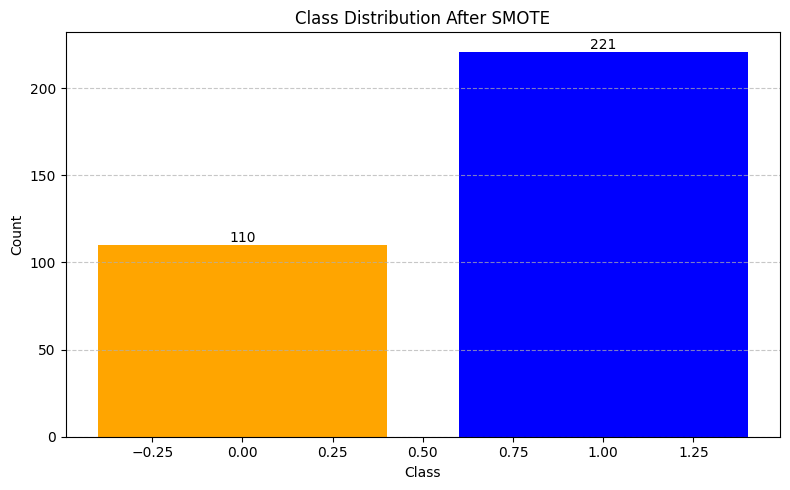

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# Original class distribution
original_counts = Counter(y)
print("Full dataset class distribution:", original_counts)  # e.g., Counter({1: 276, 0: 114})

# After stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
original_y_train_counts = Counter(y_train)
print("Original y_train distribution after split:", original_y_train_counts)  # e.g., Counter({1: 221, 0: 91})

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
smote_y_train_counts = Counter(y_train_smote)
print("y_train distribution after applying SMOTE:", smote_y_train_counts)  # e.g., Counter({1: 221, 0: 221})

# Prepare data for plotting
distributions = {
    'Original': original_y_train_counts,
    'After SMOTE': smote_y_train_counts
}

# Create a DataFrame for plotting
plot_data = pd.DataFrame(distributions).fillna(0).astype(int)

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_data.index, plot_data['After SMOTE'], color=['blue', 'orange'])
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Adding count labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KNN + SMOTE (N=5)

In [13]:
from collections import Counter

# Check class distribution after oversampling
counter = Counter(smote_y_train_counts)
print('Class distribution after SMOTE:', counter)

# Train KNN on the oversampled data
k = 5  # Choose your desired value for k
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_smote, y_train_smote)

# Make predictions and evaluate
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy for KNN with Oversampling (k={k}): {accuracy:.2f}')

report = classification_report(y_test, y_pred)
print("\nClassification Report:\n")
print(report)
print('Confusion Matrix (after SMOTE):')
print(confusion_matrix(y_test, y_pred))

Class distribution after SMOTE: Counter({1: 221, 0: 110})
Accuracy for KNN with Oversampling (k=5): 0.68

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.52      0.49        23
           1       0.79      0.75      0.77        55

    accuracy                           0.68        78
   macro avg       0.62      0.63      0.63        78
weighted avg       0.69      0.68      0.68        78

Confusion Matrix (after SMOTE):
[[12 11]
 [14 41]]


Grid Search with 10-Fold Cross-Validation

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Perform GridSearchCV with 10-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)
best_knn = grid_search.best_estimator_
print('Best KNN parameters:', grid_search.best_params_)

# Evaluate the best model using k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = []

for train_idx, val_idx in kfold.split(X_train_smote, y_train_smote):
    # Use .iloc to access rows by integer location
    X_train_fold, X_val_fold = X_train_smote.iloc[train_idx], X_train_smote.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_smote.iloc[train_idx], y_train_smote.iloc[val_idx]

    best_knn.fit(X_train_fold, y_train_fold)
    y_pred_val = best_knn.predict(X_val_fold)
    cv_results.append((y_val_fold, y_pred_val))

# Train and evaluate on the full training set with the best KNN model
best_knn.fit(X_train_smote, y_train_smote)
y_pred_test = best_knn.predict(X_test_scaled)

# Evaluation Metrics on the test set
print('Final Evaluation on Test Set:')
print('Classification Report :')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))


Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Final Evaluation on Test Set:
Classification Report :
              precision    recall  f1-score   support

           0       0.47      0.65      0.55        23
           1       0.83      0.69      0.75        55

    accuracy                           0.68        78
   macro avg       0.65      0.67      0.65        78
weighted avg       0.72      0.68      0.69        78

Confusion Matrix:
[[15  8]
 [17 38]]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate the mean weighted and macro F1 score
mean_weighted_f1 = f1_score(y_test, y_pred_test, average='weighted')
mean_macro_f1 = f1_score(y_test, y_pred_test, average='macro')

# Calculate precision and recall
mean_weighted_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
mean_macro_precision = precision_score(y_test, y_pred_test, average='macro', zero_division=0)

mean_weighted_recall = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
mean_macro_recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)

# Print the results
print('Mean Weighted F1 Score:', mean_weighted_f1)
print('Mean Macro F1 Score:', mean_macro_f1)
print('Mean Weighted Precision:', mean_weighted_precision)
print('Mean Macro Precision:', mean_macro_precision)
print('Mean Weighted Recall:', mean_weighted_recall)
print('Mean Macro Recall:', mean_macro_recall)

Mean Weighted F1 Score: 0.6914306815296914
Mean Macro F1 Score: 0.648964896489649
Mean Weighted Precision: 0.7207183667781495
Mean Macro Precision: 0.6474184782608696
Mean Weighted Recall: 0.6794871794871795
Mean Macro Recall: 0.6715415019762846


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


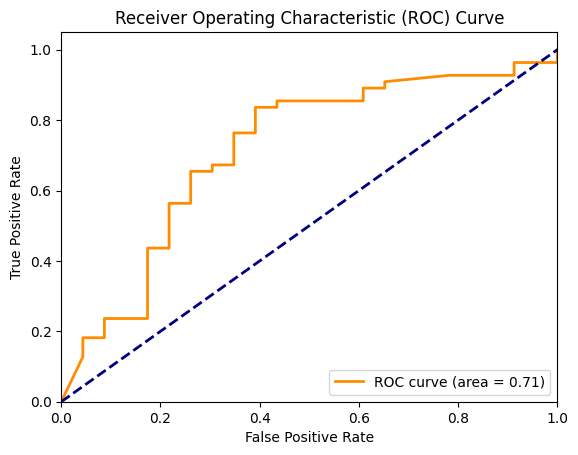

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC Curve for the full test set evaluation
y_proba = best_knn.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=best_knn.classes_[1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Naive Bayes

In [17]:
# Check class distribution after oversampling
counter = Counter(smote_y_train_counts)
print('Class distribution after SMOTE:', counter)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)
gnb = GaussianNB()

# Fit the model on the training data
gnb.fit(X_train_scaled, y_train_smote)

# Make predictions on the test set
y_pred_test = gnb.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

Class distribution after SMOTE: Counter({1: 221, 0: 110})
Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.70      0.57        23
           1       0.84      0.69      0.76        55

    accuracy                           0.69        78
   macro avg       0.66      0.69      0.67        78
weighted avg       0.74      0.69      0.70        78

Confusion Matrix:
[[16  7]
 [17 38]]


Naive bayes with Majority voting

Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.70      0.57        23
           1       0.84      0.69      0.76        55

    accuracy                           0.69        78
   macro avg       0.66      0.69      0.67        78
weighted avg       0.74      0.69      0.70        78

Confusion Matrix:
[[16  7]
 [17 38]]


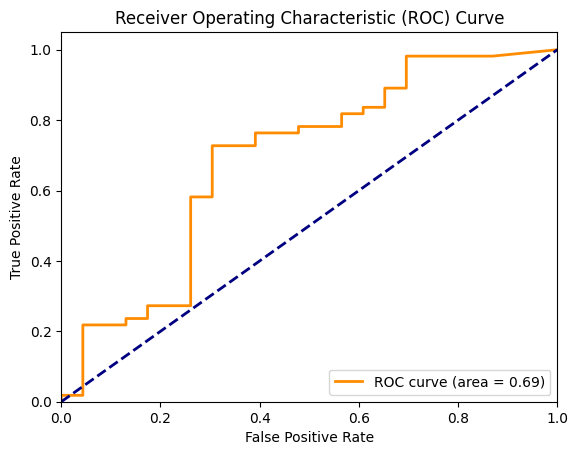

10-fold Cross-validation results:
Mean accuracy: 0.6860
***************************

Mean precision macro: 0.6753
***************************

Mean recall macro: 0.6784
***************************

Mean f1 macro: 0.6616
***************************

Mean precision weighted: 0.7191
***************************

Mean recall weighted: 0.6860
***************************

Mean f1 weighted: 0.6888
***************************



In [18]:
# Naive Bayes classifier
gnb = GaussianNB()

# Perform k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    gnb.fit(X_train_fold, y_train_fold)
    y_pred_val = gnb.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
gnb.fit(X_train_scaled, y_train_smote)
y_pred_test = gnb.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = gnb.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("10-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")

    print("***************************\n")

Logistic regression with Majority Voting

Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        23
           1       0.86      0.87      0.86        55

    accuracy                           0.81        78
   macro avg       0.77      0.76      0.77        78
weighted avg       0.81      0.81      0.81        78

Confusion Matrix:
[[15  8]
 [ 7 48]]


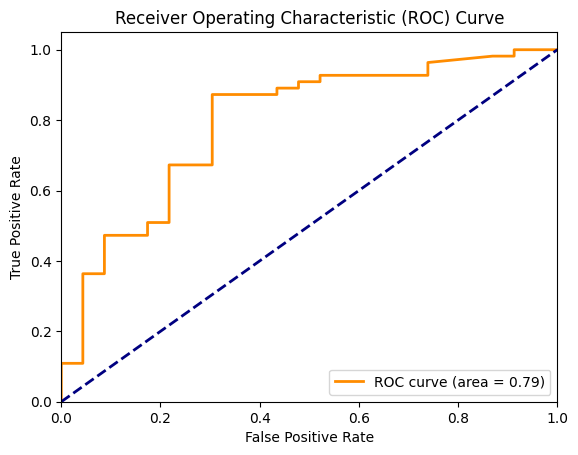

10-fold Cross-validation results:
Mean accuracy: 0.7279
***************************

Mean precision macro: 0.7027
***************************

Mean recall macro: 0.6708
***************************

Mean f1 macro: 0.6699
***************************

Mean precision weighted: 0.7275
***************************

Mean recall weighted: 0.7279
***************************

Mean f1 weighted: 0.7145
***************************



In [19]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Perform k-fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    log_reg.fit(X_train_fold, y_train_fold)
    y_pred_val = log_reg.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# Majority voting for classification on the test set
log_reg.fit(X_train_scaled, y_train_smote)
y_pred_test = log_reg.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = log_reg.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("10-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")

    print("***************************\n")


Logistic Regression classifier with grid search for hyperparameter tuning

In [20]:
# Define Logistic Regression classifier with grid search for hyperparameter tuning
log_reg = LogisticRegression(solver='liblinear')
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(log_reg, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_smote, y_train_smote)
best_log_reg = grid_search.best_estimator_
print('Best Logistic Regression parameters:', grid_search.best_params_)

# Perform k-fold cross-validation
#kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
#cv_results = []
#y_pred_test = np.zeros_like(y_test)

#for train_idx, val_idx in kfold.split(X_train_sm, y_train_sm):
    # Use numpy indexing
   # X_train_fold, X_val_fold = X_train_sm.values[train_idx], X_train_sm.values[val_idx]
   # y_train_fold, y_val_fold = y_train_sm.values[train_idx], y_train_sm.values[val_idx]

    #best_log_reg.fit(X_train_fold, y_train_fold)
   # y_pred_val = best_log_reg.predict(X_val_fold)
    #cv_results.append((y_val_fold, y_pred_val))

# Majority voting for classification on the test set
#best_log_reg.fit(X_train_sm, y_train_sm)
##y_pred_test = best_log_reg.predict(X_test_scaled)

# Evaluation Metrics
#print('Classification Report:')
#print(classification_report(y_test, y_pred_test, zero_division=0))

#print('Confusion Matrix:')
#print(confusion_matrix(y_test, y_pred_test))



# Display results from cross-validation
#for i, (y_true, y_pred) in enumerate(cv_results):
   # print(f'Fold {i+1}:')
    #print('Classification Report:')
    #print(classification_report(y_true, y_pred, zero_division=0))
    #print('Confusion Matrix:')
    #print(confusion_matrix(y_true, y_pred))
    #print()

Best Logistic Regression parameters: {'C': 0.1, 'penalty': 'l2'}


Weighted KNN with grid search

Best KNN parameters: {'leaf_size': 10, 'n_neighbors': 3}
Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.43      0.49        23
           1       0.78      0.85      0.82        55

    accuracy                           0.73        78
   macro avg       0.67      0.64      0.65        78
weighted avg       0.72      0.73      0.72        78

Confusion Matrix:
[[10 13]
 [ 8 47]]


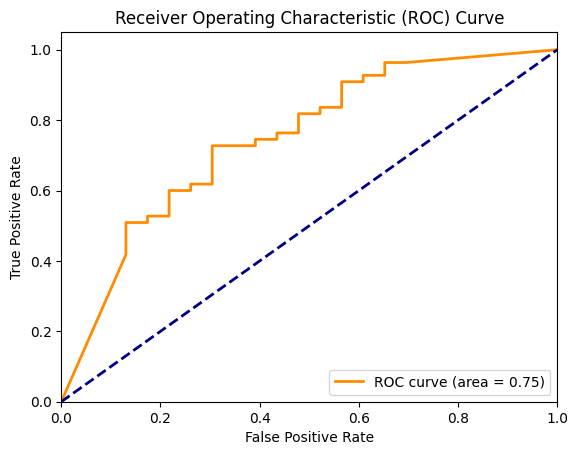

10-fold Cross-validation results:
Mean accuracy: 0.7250
Standard Deviation accuracy: 0.0854
***************************

Mean precision macro: 0.7028
Standard Deviation precision macro: 0.1095
***************************

Mean recall macro: 0.6939
Standard Deviation recall macro: 0.0957
***************************

Mean f1 macro: 0.6905
Standard Deviation f1 macro: 0.0944
***************************

Mean precision weighted: 0.7363
Standard Deviation precision weighted: 0.0939
***************************

Mean recall weighted: 0.7250
Standard Deviation recall weighted: 0.0854
***************************

Mean f1 weighted: 0.7242
Standard Deviation f1 weighted: 0.0841
***************************



In [21]:
knn_classifier = KNeighborsClassifier(weights='distance')  # Use 'distance' for weighted KNN

# Define parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'leaf_size': [10, 20, 30],
}

# Perform GridSearchCV with 10-fold cross-validation for KNN
grid_search_knn = GridSearchCV(knn_classifier, param_grid_knn, cv=10, scoring='accuracy')
grid_search_knn.fit(X_train_scaled, y_train_smote)
best_knn_classifier = grid_search_knn.best_estimator_
print('Best KNN parameters:', grid_search_knn.best_params_)

# Perform k-fold cross-validation on the training set
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store predictions for each fold
y_pred_folds = np.zeros_like(y_train_smote)

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    best_knn_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = best_knn_classifier.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

#classification on the test set
best_knn_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test = best_knn_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve (adjust pos_label if necessary based on your classes)
y_proba = best_knn_classifier.predict_proba(X_test_scaled)[:, 1]  # Get probabilities for the positive class
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("10-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")

Decision Tree with grid search

Best Decision Tree parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.57      0.50        23
           1       0.80      0.71      0.75        55

    accuracy                           0.67        78
   macro avg       0.62      0.64      0.62        78
weighted avg       0.69      0.67      0.68        78

Confusion Matrix:
[[13 10]
 [16 39]]


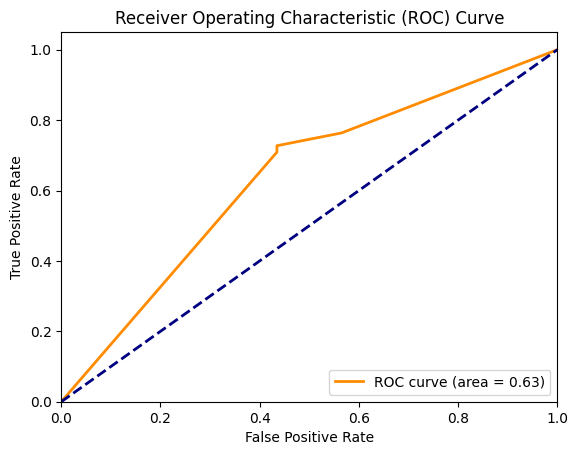

10-fold Cross-validation results:
Mean accuracy: 0.6523
***************************

Mean precision macro: 0.6107
***************************

Mean recall macro: 0.6143
***************************

Mean f1 macro: 0.6082
***************************

Mean precision weighted: 0.6573
***************************

Mean recall weighted: 0.6523
***************************

Mean f1 weighted: 0.6510
***************************



In [22]:
# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Decision Tree classifier

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV with 10-fold cross-validation using custom scoring
grid_search = GridSearchCV(dt_classifier, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train_smote)
best_dt_classifier = grid_search.best_estimator_
print('Best Decision Tree parameters:', grid_search.best_params_)

# Perform 10-fold cross-validation on the training set
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store the predictions from each fold
y_pred_folds = np.zeros_like(y_train_smote)

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    dt_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = dt_classifier.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
dt_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test = dt_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = dt_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("10-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")

    print("***************************\n")


RandomForest with GridSearch and Hypertuning

In [23]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [3, 4, 5],          # Maximum depth of individual trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required at each leaf node
}

# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Perform GridSearchCV with 10-fold cross-validation using custom scoring
grid_search = GridSearchCV(rf_classifier, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train_smote)
best_rf_classifier = grid_search.best_estimator_
print('Best Random Forest parameters:', grid_search.best_params_)

# Perform 10-fold cross-validation on the training set
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store the predictions from each fold
y_pred_folds = np.zeros_like(y_train_smote)

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    rf_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = rf_classifier.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
rf_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test = rf_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = rf_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt
print("k-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")

Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.52      0.63        23
           1       0.83      0.95      0.88        55

    accuracy                           0.82        78
   macro avg       0.81      0.73      0.76        78
weighted avg       0.82      0.82      0.81        78

Confusion Matrix:
[[12 11]
 [ 3 52]]
k-fold Cross-validation results:
Mean accuracy: 0.7488
Standard Deviation accuracy: 0.0874
***************************

Mean precision macro: 0.7332
Standard Deviation precision macro: 0.1291
***************************

Mean recall macro: 0.6797
Standard Deviation recall macro: 0.1052
***************************

Mean f1 macro: 0.6858
Standard Deviation f1 macro: 0.1115
***************************

Mean precision weighted: 0.7471
Standard Deviation precision wei

XGBOOST with grid search and hypertunning

In [24]:
# Perform k-fold cross-validation on the training set
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}
xgb_classifier = XGBClassifier(eval_metric='mlogloss', random_state=42)

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

# Perform GridSearchCV with 10-fold cross-validation for XGBoost
grid_search_xgb = GridSearchCV(xgb_classifier, param_grid_xgb, cv=10, scoring='accuracy')
grid_search_xgb.fit(X_train_scaled, y_train_smote)
best_xgb_classifier = grid_search_xgb.best_estimator_
print('Best XGBoost parameters:', grid_search_xgb.best_params_)

Best XGBoost parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 50, 'subsample': 1.0}


Final Evaluation on Test Set:
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.61      0.56        23
           1       0.82      0.76      0.79        55

    accuracy                           0.72        78
   macro avg       0.67      0.69      0.68        78
weighted avg       0.73      0.72      0.72        78

Confusion Matrix:
[[14  9]
 [13 42]]


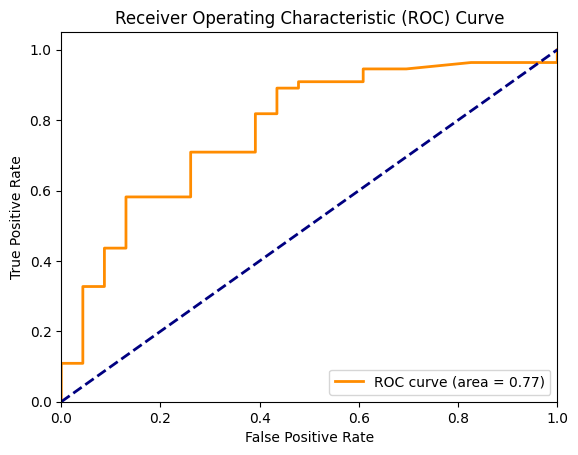

k-fold Cross-validation results:
Mean accuracy: 0.8304
Standard Deviation accuracy: 0.0488
***************************

Mean precision macro: 0.8369
Standard Deviation precision macro: 0.0479
***************************

Mean recall macro: 0.8305
Standard Deviation recall macro: 0.0487
***************************

Mean f1 macro: 0.8295
Standard Deviation f1 macro: 0.0492
***************************

Mean precision weighted: 0.8370
Standard Deviation precision weighted: 0.0479
***************************

Mean recall weighted: 0.8304
Standard Deviation recall weighted: 0.0488
***************************

Mean f1 weighted: 0.8295
Standard Deviation f1 weighted: 0.0492
***************************



In [ ]:
# Store predictions for each fold
y_pred_folds = np.zeros_like(y_train_smote)

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    xgb_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = xgb_classifier.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
xgb_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test = xgb_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = xgb_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("k-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")

Lightgbm with Gridsearch and hypertunning

In [25]:
# Perform k-fold cross-validation on the training set
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_results = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}
lgbm_classifier = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.1, num_leaves=31, random_state=42)

# Define parameter grid for LGBM
param_grid_lgbm = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [20, 31],
    'max_depth': [-1, 10],
    'min_child_samples': [5, 10],
}

# Perform GridSearchCV with 10-fold cross-validation for LGBM
grid_search_lgbm = GridSearchCV(lgbm_classifier, param_grid_lgbm, cv=10, scoring='accuracy')
grid_search_lgbm.fit(X_train_scaled, y_train_smote)
best_lgbm_classifier = grid_search_lgbm.best_estimator_
print('Best LGBM parameters:', grid_search_lgbm.best_params_)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[LightGBM] [Info] Number of positive: 221, number of negative: 110
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81
[LightGBM] [Info] Number of data points in the train set: 331, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.667674 -> initscore=0.697682
[LightGBM] [Info] Start training from score 0.697682
Best LGBM parameters: {'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 500, 'num_leaves': 20}


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

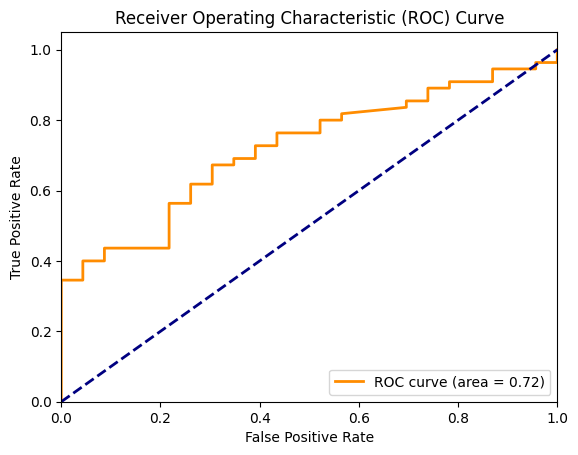

k-fold Cross-validation results:
Mean accuracy: 0.7431
Standard Deviation accuracy: 0.0972
***************************

Mean precision macro: 0.7171
Standard Deviation precision macro: 0.1071
***************************

Mean recall macro: 0.7166
Standard Deviation recall macro: 0.1115
***************************

Mean f1 macro: 0.7113
Standard Deviation f1 macro: 0.1085
***************************

Mean precision weighted: 0.7514
Standard Deviation precision weighted: 0.0980
***************************

Mean recall weighted: 0.7431
Standard Deviation recall weighted: 0.0972
***************************

Mean f1 weighted: 0.7425
Standard Deviation f1 weighted: 0.0969
***************************



In [26]:
# Store predictions for each fold
y_pred_folds = np.zeros_like(y_train_smote)

for train_idx, val_idx in kfold.split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    lgbm_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = lgbm_classifier.predict(X_val_fold)

    metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
lgbm_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test = lgbm_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set:')
print('Classification Report:')
print(classification_report(y_test, y_pred_test, zero_division=0))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_test))

# ROC Curve
y_proba = lgbm_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display cross-validation metrics for each fold
print("k-fold Cross-validation results:")
for metric, scores in metrics_results.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")

Gradient Boosting Classifier with Gridsearch, Hypertunning

Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
Final Evaluation on Test Set (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        23
           1       0.84      0.84      0.84        55

    accuracy                           0.77        78
   macro avg       0.72      0.72      0.72        78
weighted avg       0.77      0.77      0.77        78

[[14  9]
 [ 9 46]]
k-fold Cross-validation results (Gradient Boosting):
Mean accuracy: 0.7731
Standard Deviation accuracy: 0.0875
***************************

Mean precision macro: 0.7443
Standard Deviation precision macro: 0.1034
***************************

Mean recall macro: 0.7321
Standard Deviation recall macro: 0.1144
***************************

Mean f1 macro: 0.7314
Standard Deviation f1 macro: 0.1123
***************************

Mean precision weighted: 0.7699
Standard Deviation precision weighte

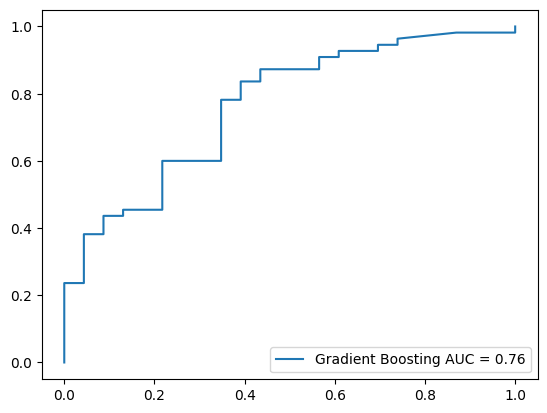

In [27]:
# Define parameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinking to prevent overfitting
    'max_depth': [3, 4, 5],            # Maximum depth of trees
    'subsample': [0.8, 0.9, 1.0],      # Fraction of samples used for fitting
}

# Initialize Gradient Boosting classifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Perform GridSearchCV with 10-fold cross-validation
grid_search_gb = GridSearchCV(gb_classifier, param_grid_gb, cv=10, scoring='accuracy')
grid_search_gb.fit(X_train_scaled, y_train_smote)
best_gb_classifier = grid_search_gb.best_estimator_
print('Best Gradient Boosting parameters:', grid_search_gb.best_params_)

# Perform 10-fold cross-validation on the training set
metrics_results_gb = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store the predictions from each fold
y_pred_folds_gb = np.zeros_like(y_train_smote)

for train_idx, val_idx in StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    gb_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = gb_classifier.predict(X_val_fold)

    metrics_results_gb['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results_gb['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_gb['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_gb['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_gb['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_gb['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_gb['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
gb_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test_gb = gb_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set (Gradient Boosting):')
print(classification_report(y_test, y_pred_test_gb, zero_division=0))
print(confusion_matrix(y_test, y_pred_test_gb))

# ROC Curve
y_proba_gb = gb_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba_gb[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc_gb = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Gradient Boosting AUC = {roc_auc_gb:.2f}')
plt.legend(loc='lower right')

# k-fold Cross-validation results
print("k-fold Cross-validation results (Gradient Boosting):")
for metric, scores in metrics_results_gb.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")


AdaBoost Classifier with Gridsearch, Hypertunning

Best AdaBoost parameters: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 50}


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

Final Evaluation on Test Set (AdaBoost):
              precision    recall  f1-score   support

           0       0.62      0.57      0.59        23
           1       0.82      0.85      0.84        55

    accuracy                           0.77        78
   macro avg       0.72      0.71      0.72        78
weighted avg       0.76      0.77      0.77        78

[[13 10]
 [ 8 47]]
k-fold Cross-validation results (AdaBoost):
Mean accuracy: 0.7218
Standard Deviation accuracy: 0.0827
***************************

Mean precision macro: 0.6953
Standard Deviation precision macro: 0.1083
***************************

Mean recall macro: 0.6639
Standard Deviation recall macro: 0.0933
***************************

Mean f1 macro: 0.6616
Standard Deviation f1 macro: 0.1057
***************************

Mean precision weighted: 0.7210
Standard Deviation precision weighted: 0.0889
***************************

Mean recall weighted: 0.7218
Standard Deviation recall weighted: 0.0827
********************

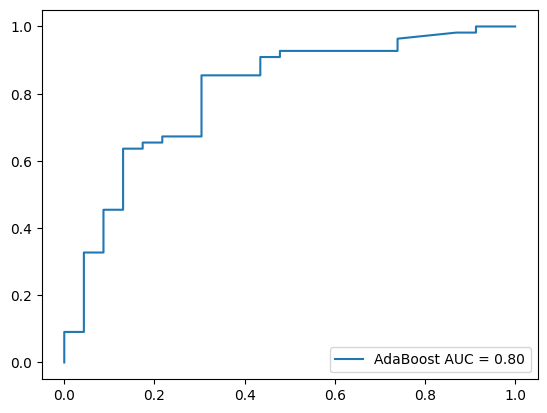

In [28]:
from sklearn.ensemble import AdaBoostClassifier

# Define parameter grid for AdaBoost
param_grid_ab = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 1.0],  # Learning rate
    'algorithm': ['SAMME']  # Explicitly using the 'SAMME' algorithm to avoid the deprecation warning
}

# Initialize AdaBoost classifier
ab_classifier = AdaBoostClassifier(random_state=42)

# Perform GridSearchCV with 10-fold cross-validation
grid_search_ab = GridSearchCV(ab_classifier, param_grid_ab, cv=10, scoring='accuracy')
grid_search_ab.fit(X_train_scaled, y_train_smote)
best_ab_classifier = grid_search_ab.best_estimator_
print('Best AdaBoost parameters:', grid_search_ab.best_params_)

# Perform 10-fold cross-validation on the training set
metrics_results_ab = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store the predictions from each fold
y_pred_folds_ab = np.zeros_like(y_train_smote)

for train_idx, val_idx in StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    ab_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = ab_classifier.predict(X_val_fold)

    metrics_results_ab['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results_ab['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_ab['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_ab['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_ab['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_ab['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_ab['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
ab_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test_ab = ab_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set (AdaBoost):')
print(classification_report(y_test, y_pred_test_ab, zero_division=0))
print(confusion_matrix(y_test, y_pred_test_ab))

# ROC Curve
y_proba_ab = ab_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba_ab[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc_ab = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AdaBoost AUC = {roc_auc_ab:.2f}')
plt.legend(loc='lower right')

# k-fold Cross-validation results
print("k-fold Cross-validation results (AdaBoost):")
for metric, scores in metrics_results_ab.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")


Extra Trees Classifier with Gridsearch, Hypertunning

Best Extra Trees parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Final Evaluation on Test Set (Extra Trees):
              precision    recall  f1-score   support

           0       0.60      0.52      0.56        23
           1       0.81      0.85      0.83        55

    accuracy                           0.76        78
   macro avg       0.71      0.69      0.69        78
weighted avg       0.75      0.76      0.75        78

[[12 11]
 [ 8 47]]
k-fold Cross-validation results (Extra Trees):
Mean accuracy: 0.7398
Standard Deviation accuracy: 0.0821
***************************

Mean precision macro: 0.7134
Standard Deviation precision macro: 0.1256
***************************

Mean recall macro: 0.6730
Standard Deviation recall macro: 0.1042
***************************

Mean f1 macro: 0.6758
Standard Deviation f1 macro: 0.1116
***************************

Mean precision weighted: 0.7336
Standard Deviation precision weighted: 0.1039
*

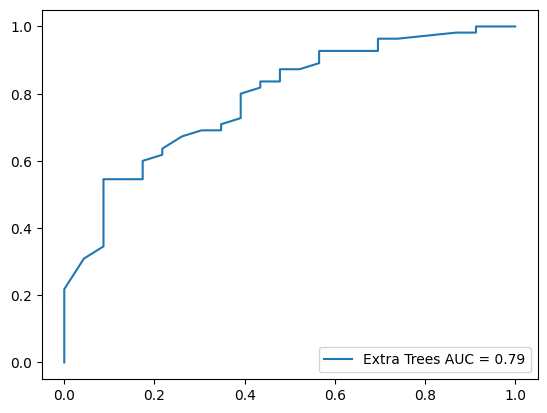

In [29]:
# Define parameter grid for Extra Trees
param_grid_et = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [3, 4, 5],            # Maximum depth of individual trees
    'min_samples_split': [2, 5, 10],   # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples required at each leaf node
}

# Initialize Extra Trees classifier
et_classifier = ExtraTreesClassifier(random_state=42)

# Perform GridSearchCV with 10-fold cross-validation
grid_search_et = GridSearchCV(et_classifier, param_grid_et, cv=10, scoring='accuracy')
grid_search_et.fit(X_train_scaled, y_train_smote)
best_et_classifier = grid_search_et.best_estimator_
print('Best Extra Trees parameters:', grid_search_et.best_params_)

# Perform 10-fold cross-validation on the training set
metrics_results_et = {
    'accuracy': [],
    'precision_macro': [],
    'recall_macro': [],
    'f1_macro': [],
    'precision_weighted': [],
    'recall_weighted': [],
    'f1_weighted': []
}

# Store the predictions from each fold
y_pred_folds_et = np.zeros_like(y_train_smote)

for train_idx, val_idx in StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_train_scaled, y_train_smote):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

    et_classifier.fit(X_train_fold, y_train_fold)
    y_pred_val = et_classifier.predict(X_val_fold)

    metrics_results_et['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
    metrics_results_et['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_et['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_et['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
    metrics_results_et['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_et['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
    metrics_results_et['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

# classification on the test set
et_classifier.fit(X_train_scaled, y_train_smote)
y_pred_test_et = et_classifier.predict(X_test_scaled)

# Evaluation Metrics on Test Set
print('Final Evaluation on Test Set (Extra Trees):')
print(classification_report(y_test, y_pred_test_et, zero_division=0))
print(confusion_matrix(y_test, y_pred_test_et))

# ROC Curve
y_proba_et = et_classifier.predict_proba(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_proba_et[:, 1], pos_label=1)  # Adjust pos_label if necessary
roc_auc_et = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Extra Trees AUC = {roc_auc_et:.2f}')
plt.legend(loc='lower right')

# k-fold Cross-validation results
print("k-fold Cross-validation results (Extra Trees):")
for metric, scores in metrics_results_et.items():
    print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
    print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
    print("***************************\n")


SVM, MLP, polynomial and catboast with gridsearch and hypertunning


Training SVM...
Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Final Evaluation on Test Set (SVM):
              precision    recall  f1-score   support

           0       0.48      0.57      0.52        23
           1       0.80      0.75      0.77        55

    accuracy                           0.69        78
   macro avg       0.64      0.66      0.65        78
weighted avg       0.71      0.69      0.70        78

[[13 10]
 [14 41]]
k-fold Cross-validation results (SVM):
Mean accuracy: 0.7611
Standard Deviation accuracy: 0.0967
***************************

Mean precision macro: 0.7421
Standard Deviation precision macro: 0.1183
***************************

Mean recall macro: 0.7163
Standard Deviation recall macro: 0.1138
***************************

Mean f1 macro: 0.7176
Standard Deviation f1 macro: 0.1147
***************************

Mean precision weighted: 0.7644
Standard Deviation precision weighted: 0.1026
***************************

Mean recall weight

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Polynomial Regression parameters: {'polynomialfeatures__degree': 2}

Final Evaluation on Test Set (Polynomial Regression):
              precision    recall  f1-score   support

           0       0.41      0.48      0.44        23
           1       0.76      0.71      0.74        55

    accuracy                           0.64        78
   macro avg       0.59      0.59      0.59        78
weighted avg       0.66      0.64      0.65        78

[[11 12]
 [16 39]]
k-fold Cross-validation results (Polynomial Regression):
Mean accuracy: 0.7220
Standard Deviation accuracy: 0.0800
***************************

Mean precision macro: 0.6917
Standard Deviation precision macro: 0.0963
***************************

Mean recall macro: 0.6894
Standard Deviation recall macro: 0.1028
***************************

Mean f1 macro: 0.6829
Standard Deviation f1 macro: 0.0971
***************************

Mean precision weighted: 0.7290
Standard Deviation precision weighted: 0.0900
*********************

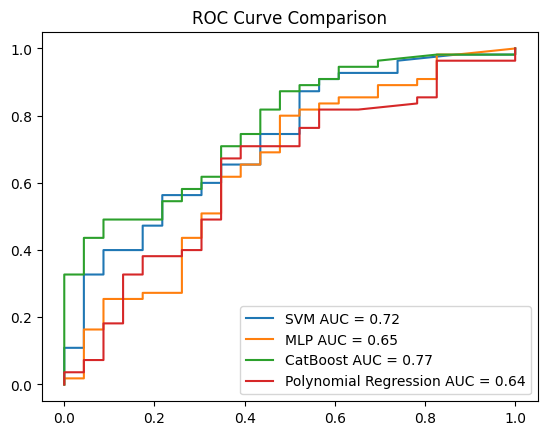

In [34]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Define parameter grid for each model
param_grid_svm = {
    'C': [0.1, 1, 10],           # Regularization parameter
    'kernel': ['linear', 'rbf'],  # Kernel type
    'gamma': ['scale', 'auto']    # Kernel coefficient
}

# Parameter grid for MLP
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],  # Size of hidden layers
    'activation': ['relu', 'tanh'],                    # Activation function
    'solver': ['adam', 'sgd'],                         # Optimization algorithm
    'alpha': [0.0001, 0.001, 0.01],                     # Regularization parameter
    'max_iter': [1000, 2000],  # Increase number of iterations
    'learning_rate_init': [0.001, 0.0001],  # Try smaller learning rates
    'early_stopping': [True],  # Use early stopping
    'n_iter_no_change': [10]   # Stop after 10 iterations with no improvement
}

param_grid_catboost = {
    'iterations': [100, 200],       # Number of boosting iterations
    'depth': [3, 4, 5],             # Depth of the trees
    'learning_rate': [0.01, 0.1],   # Learning rate
    'l2_leaf_reg': [1, 3]           # L2 regularization
}

param_grid_poly = {
    'polynomialfeatures__degree': [2, 3]  # Corrected parameter name for PolynomialFeatures
}

# Initialize classifiers
svm_classifier = SVC(probability=True, random_state=42)
mlp_classifier = MLPClassifier(random_state=42)
catboost_classifier = CatBoostClassifier(learning_rate=0.1, depth=3, iterations=100, random_state=42, verbose=0)
poly_classifier = make_pipeline(PolynomialFeatures(), LogisticRegression())

# Models dictionary to loop over
models = {
    'SVM': (svm_classifier, param_grid_svm),
    'MLP': (mlp_classifier, param_grid_mlp),
    'CatBoost': (catboost_classifier, param_grid_catboost),
    'Polynomial Regression': (poly_classifier, param_grid_poly)
}

# Perform GridSearchCV and k-fold cross-validation for each model
for model_name, (model, param_grid) in models.items():
    print(f"\nTraining {model_name}...")

    # Perform GridSearchCV
    grid_search = GridSearchCV(model, param_grid, cv=10, scoring='accuracy')
    grid_search.fit(X_train_scaled, y_train_smote)
    best_model = grid_search.best_estimator_
    print(f"Best {model_name} parameters:", grid_search.best_params_)

    # k-fold Cross-validation results
    metrics_results = {
        'accuracy': [],
        'precision_macro': [],
        'recall_macro': [],
        'f1_macro': [],
        'precision_weighted': [],
        'recall_weighted': [],
        'f1_weighted': []
    }

    # Store predictions for each fold
    y_pred_folds = np.zeros_like(y_train_smote)

    # Perform Stratified K-fold cross-validation
    for train_idx, val_idx in StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_train_scaled, y_train_smote):
        X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_train_fold, y_val_fold = y_train_smote[train_idx], y_train_smote[val_idx]

        best_model.fit(X_train_fold, y_train_fold)
        y_pred_val = best_model.predict(X_val_fold)

        metrics_results['accuracy'].append(accuracy_score(y_val_fold, y_pred_val))
        metrics_results['precision_macro'].append(precision_score(y_val_fold, y_pred_val, average='macro'))
        metrics_results['recall_macro'].append(recall_score(y_val_fold, y_pred_val, average='macro'))
        metrics_results['f1_macro'].append(f1_score(y_val_fold, y_pred_val, average='macro'))
        metrics_results['precision_weighted'].append(precision_score(y_val_fold, y_pred_val, average='weighted'))
        metrics_results['recall_weighted'].append(recall_score(y_val_fold, y_pred_val, average='weighted'))
        metrics_results['f1_weighted'].append(f1_score(y_val_fold, y_pred_val, average='weighted'))

    # Final classification on the test set
    best_model.fit(X_train_scaled, y_train_smote)
    y_pred_test = best_model.predict(X_test_scaled)

    # Evaluate metrics on the test set
    print(f'\nFinal Evaluation on Test Set ({model_name}):')
    print(classification_report(y_test, y_pred_test, zero_division=0))
    print(confusion_matrix(y_test, y_pred_test))

    # ROC Curve (Only if model has probability output)
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test_scaled)
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1], pos_label=1)  # Adjust pos_label if necessary
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{model_name} AUC = {roc_auc:.2f}')
    else:
        print(f"{model_name} does not have probability predictions (No ROC curve available).")

    # k-fold Cross-validation results
    print(f"k-fold Cross-validation results ({model_name}):")
    for metric, scores in metrics_results.items():
        print(f"Mean {metric.replace('_', ' ')}: {np.mean(scores):.4f}")
        print(f"Standard Deviation {metric.replace('_', ' ')}: {np.std(scores):.4f}")
        print("***************************\n")

# Plot the ROC curves for models that support it
plt.legend(loc='lower right')
plt.title('ROC Curve Comparison')
plt.show()
